<a href="https://colab.research.google.com/github/sergeyarefjev/study/blob/main/ml/neural_network_learn_ff/predict_loan_payback.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! pip install optuna
! pip install catboost
! pip install torch
! pip install pytabkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.3/363.3 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 56.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve, CalibrationDisplay
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import optuna
import cupy as cp
import torch
import torch.nn as nn
import torch.optim as optim
from pytabkit import TabM_D_Classifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC


In [ ]:
def set_global_seed(seed=42):
    np.random.seed(seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_global_seed(42)

# Istalling data

In [ ]:
train_ = pd.read_csv("/content/drive/MyDrive/ML_data/predict_loan_payback/train.csv")
test_ = pd.read_csv("/content/drive/MyDrive/ML_data/predict_loan_payback/test.csv")
origin_data_ = pd.read_csv("/content/drive/MyDrive/ML_data/predict_loan_payback/loan_dataset_20000.csv")
print(train_.shape)
print(test_.shape)
print(origin_data_.shape)

(593994, 13)
(254569, 12)
(20000, 22)


In [ ]:
target = "loan_paid_back"

# Information of data

In [ ]:
categorical = ["gender", "marital_status", "education_level", "employment_status", "loan_purpose",
            "grade_subgrade"]
numeric = ["annual_income", "debt_to_income_ratio", "credit_score", "loan_amount", "interest_rate"]
train_.columns

Index(['id', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 'gender', 'marital_status',
       'education_level', 'employment_status', 'loan_purpose',
       'grade_subgrade', 'loan_paid_back'],
      dtype='object')

In [ ]:
def check_mean_target(df, column, target):
    d_1 = df.groupby(column)[target].count()
    d_2 = df.groupby(column)[target].mean()

    plt.bar(d_1.index, d_1.values)
    plt.title(f"Count of each category by {column}")
    plt.show()
    plt.bar(d_2.index, d_2.values)
    plt.title(f"Mean target of each category by {column}")
    plt.show()

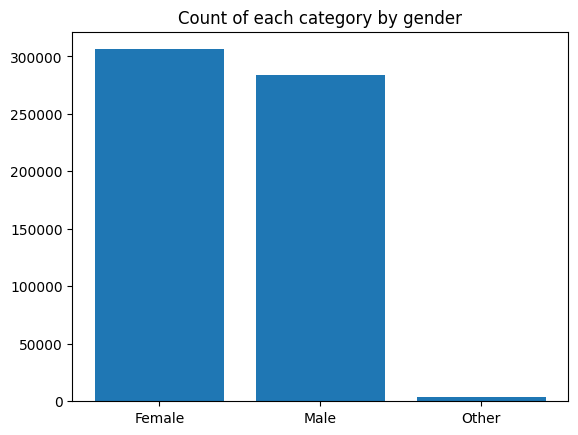

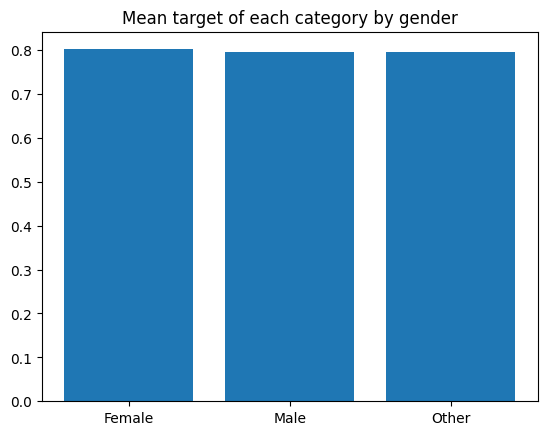

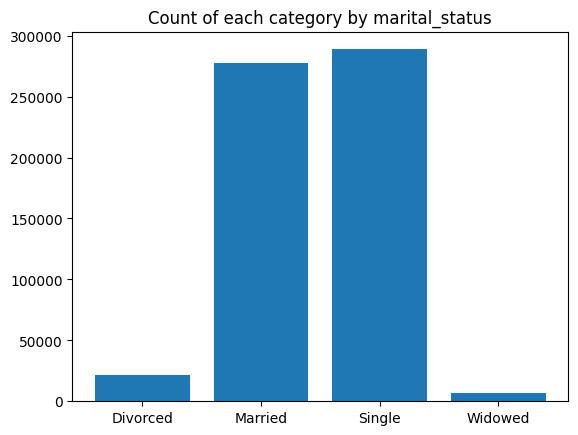

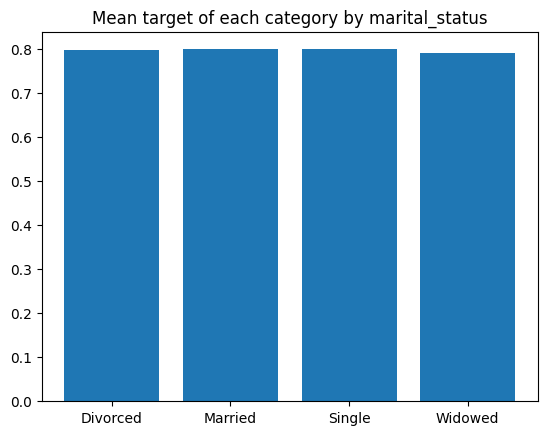

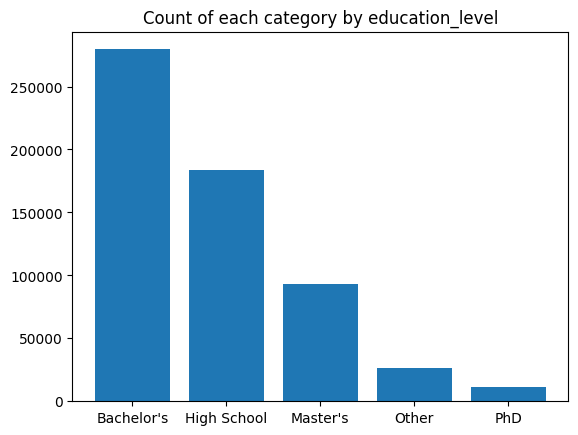

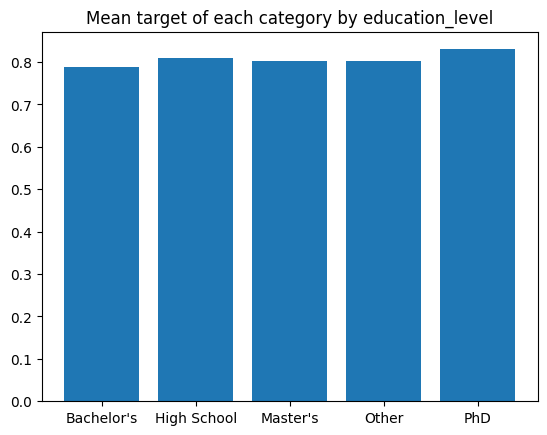

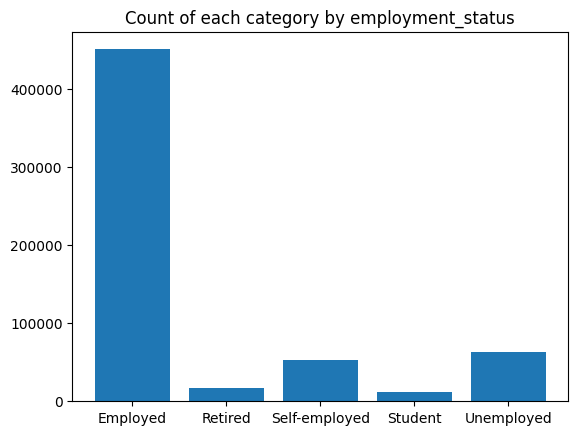

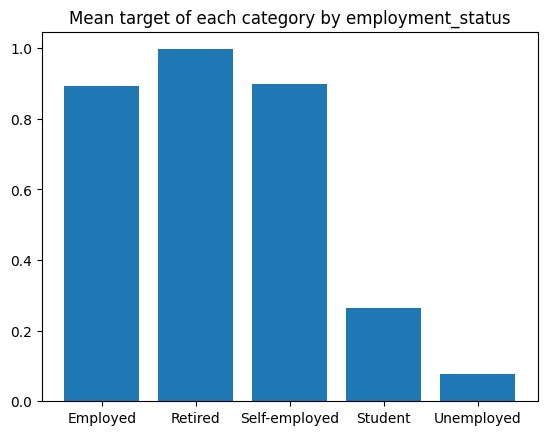

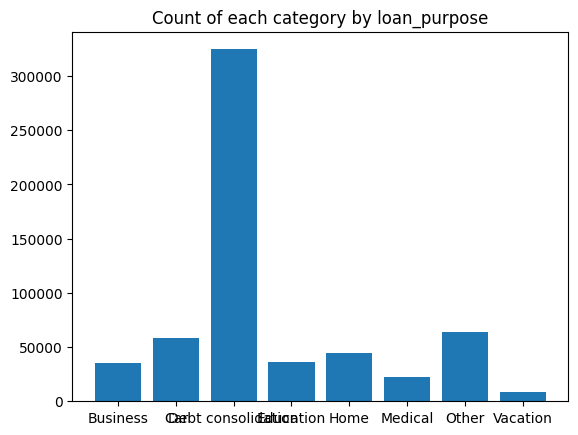

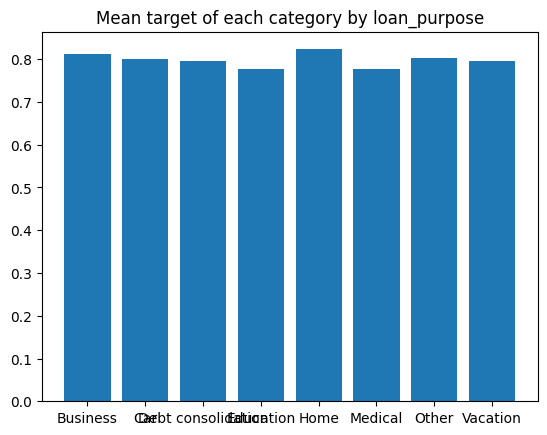

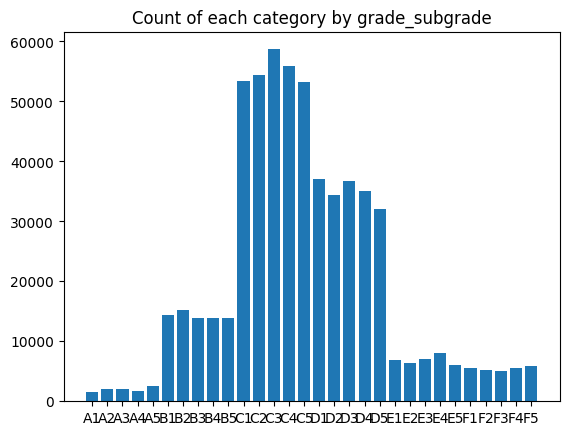

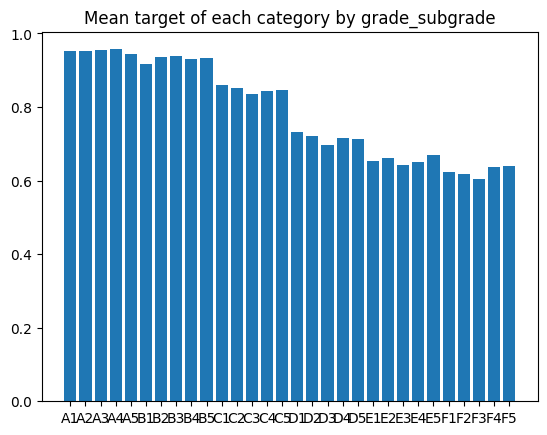

In [ ]:
for column in categorical:
    check_mean_target(train_, column, target)

Из приведенного выше созвездия графиков видно, что gender, maritial_status - практически бесполезны, возможно в дальнейшем их выкинем
grade_subgrade - можно кодировать либо через target encoding либо через самый дефолтный, забыл как называется, так как много классов и есть некая линейная динамика (что логично из определения grade_subgrade)
В остальных случаях есть релевантная связь с таргетом

In [ ]:
for column in numeric:
    print(f"{column} unique value {len(np.unique(train_[column]))}")

annual_income unique value 119728
debt_to_income_ratio unique value 526
credit_score unique value 399
loan_amount unique value 111570
interest_rate unique value 1454


# Preprocessing kdmitriev

In [ ]:
from itertools import combinations

class FeatureEngineer:
    def __init__(self, df: pd.DataFrame, target: str) -> None:
        self.df = df
        self.target = target

    def columns_x_info(self) -> tuple[list, list]:
        """
        Print the dataframe columns info and split columns by their type
        Target columns is skipped, so only X columns are analysed
        """
        categoric = []
        numeric = []
        for col in self.df.columns:
            if col in [self.target, '_dataset']:
                continue

            if self.df[col].dtype == 'object':
                categoric.append(col)
                tp = 'CAT'
            else:
                numeric.append(col)
                tp = 'NUM'
            num_values = self.df[col].nunique()
            nans = self.df[col].isna().sum()
            print(f"[{tp}] {col} has {num_values} unique values and {nans} NANs")
        print("Categoric:", categoric )
        print("Numeric:", numeric )
        return categoric, numeric

    def label_encoder_categoric(self, categoric: list[str]) -> None:
        """
        Inplace transform all categoric columns to the columns with integer-only values
        """
        for col in categoric:
            self.df[col] = self.df[col].factorize()[0].astype('int32')

    def label_encoder_numeric(self, numeric: list[str], suffix: str = '_cat') -> list[str]:
        """
        Inplace duplicate numeric columns transforming them to categorical ones
        """
        new_cols = []
        for col in numeric:
            self.df[col + suffix] = self.df[col].factorize()[0].astype('int32')
            new_cols.append(col + suffix)
        return new_cols

    def create_categoric_pairs(self, categoric: list[str], inplace: bool=True) -> pd.DataFrame:
        """
        Combine previously label-encoded categorical columns into one new dataframe
        """
        pairs = combinations(categoric, 2)
        combined_df = {}
        for col1, col2 in pairs:
            combined = "_".join(sorted((col1, col2)))
            combined_df[combined] = self.df[col1] * (1 + max(self.df[col2])) + self.df[col2]
        combined_df = pd.DataFrame(combined_df)

        if inplace:
            self.df = pd.concat([self.df, combined_df], axis=1)

        return combined_df

    def count_encoder_categoric(self, categoric: list[str], suffix: str='_cnt') -> list[str]:
        """
        Inplace addition of count-encoded categorical columns
        """
        new_cols = []
        for col in categoric:
            col_cnt = self.df.groupby(col)[self.target].count().astype('int32')
            col_cnt.name = col + suffix
            new_cols.append(col_cnt.name)
            self.df = self.df.merge(col_cnt, on=col, how='left')
        return new_cols

    def target_encoder_categoric(self, categoric: list[str], dataset: pd.DataFrame, suffix: str='_trg') -> list[str]:
        """
        Inplace addition of target-encoded categorical columns using the specified dataset for calculations
        """
        new_cols = []
        for col in categoric:
            col_trg = dataset.groupby(col)[self.target].mean()
            col_trg.name = col + suffix
            new_cols.append(col_trg.name)
            self.df = self.df.merge(col_trg, on=col, how='left')
        return new_cols

    def add_specific_transforms(self):
        """
        Create some specific columns
        """
        # Grade
        self.df['grade'] = self.df['grade_subgrade'].str[0]

        # Credit score tiers
        self.df['credit_score_FICO_tier'] = self.df['credit_score'].apply(map_fico_tier)
        self.df['credit_score_Vantage_tier'] = self.df['credit_score'].apply(map_vantage_tier)


    def add_financial_transforms(self):
        """
        Add some financial columns
        """
        # Core affordability
        self.df['income_loan_ratio'] = self.df['annual_income'] / (self.df['loan_amount'] + 1)
        self.df['loan_to_income'] = self.df['loan_amount'] / (self.df['annual_income'] + 1)

        # Debt metrics
        self.df['total_debt'] = self.df['debt_to_income_ratio'] * self.df['annual_income']
        self.df['available_income'] = self.df['annual_income'] * (1 - self.df['debt_to_income_ratio'])
        self.df['debt_burden'] = self.df['debt_to_income_ratio'] * self.df['loan_amount']

        # Payment analysis
        self.df['monthly_payment'] = self.df['loan_amount'] * self.df['interest_rate'] / 1200
        self.df['payment_to_income'] = self.df['monthly_payment'] / (self.df['annual_income'] / 12 + 1)
        self.df['affordability'] = self.df['available_income'] / (self.df['loan_amount'] + 1)

        # Risk scoring
        self.df['default_risk'] = (self.df['debt_to_income_ratio'] * 0.40 +
                            (850 - self.df['credit_score']) / 850 * 0.35 +
                            self.df['interest_rate'] / 100 * 0.25)

        # Credit analysis
        self.df['credit_utilization'] = self.df['credit_score'] * (1 - self.df['debt_to_income_ratio'])
        self.df['credit_interest_product'] = self.df['credit_score'] * self.df['interest_rate'] / 100

        # Log transformations
        for col in ['annual_income', 'loan_amount']:
            self.df[f'{col}_log'] = np.log1p(self.df[col])

        # Grade parsing
        self.df['grade_letter'] = self.df['grade_subgrade'].str[0]
        self.df['grade_number'] = self.df['grade_subgrade'].str[1].astype(int)
        grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
        self.df['grade_rank'] = self.df['grade_letter'].map(grade_map)

        return self.df

    def astype(self, columns, to_type):
        self.df[columns] = self.df[columns].astype(to_type)


def map_fico_tier(score):
    """Maps a credit score to its corresponding FICO tier."""
    if score >= 800:
        return 'Exceptional'
    elif score >= 740:
        return 'Very Good'
    elif score >= 670:
        return 'Good'
    elif score >= 580:
        return 'Fair'
    else: # Below 580
        return 'Poor'

def map_vantage_tier(score):
    """Maps a credit score to its corresponding VantageScore tier."""
    if score >= 781:
        return 'Excellent'
    elif score >= 661:
        return 'Good'
    elif score >= 601:
        return 'Fair'
    elif score >= 500:
        return 'Poor'
    else: # Below 500
        return 'Very Poor'

In [ ]:
df = pd.concat([train_, test_], axis=0, ignore_index=True)

cat1, cat2 = [], []

fe = FeatureEngineer(df, target)

categoric, numeric = fe.columns_x_info()
fe.label_encoder_categoric(categoric)
cat1 = fe.label_encoder_numeric(numeric)                            #
fe.astype(numeric, 'int32')
categoric += cat1

#combined_df = fe.create_categoric_pairs(categoric, inplace=True)    #
#cat2 = list(combined_df.columns)
#categoric += cat2

fe.count_encoder_categoric(categoric)                               #
df.head(20)

[NUM] id has 848563 unique values and 0 NANs
[NUM] annual_income has 151992 unique values and 0 NANs
[NUM] debt_to_income_ratio has 537 unique values and 0 NANs
[NUM] credit_score has 402 unique values and 0 NANs
[NUM] loan_amount has 138759 unique values and 0 NANs
[NUM] interest_rate has 1489 unique values and 0 NANs
[CAT] gender has 3 unique values and 0 NANs
[CAT] marital_status has 4 unique values and 0 NANs
[CAT] education_level has 5 unique values and 0 NANs
[CAT] employment_status has 5 unique values and 0 NANs
[CAT] loan_purpose has 8 unique values and 0 NANs
[CAT] grade_subgrade has 30 unique values and 0 NANs
Categoric: ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']
Numeric: ['id', 'annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']


,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,id_cat,annual_income_cat,debt_to_income_ratio_cat,credit_score_cat,loan_amount_cat,interest_rate_cat
0,0,29367,0,736,2528,13,0,0,0,0,0,0,1.0,0,0,0,0,0,0
1,1,22108,0,636,4593,12,1,1,1,1,1,1,0.0,1,1,1,1,1,1
2,2,49566,0,694,17005,9,1,0,0,1,1,2,1.0,2,2,2,2,2,2
3,3,46858,0,533,4682,16,0,0,0,1,1,3,1.0,3,3,3,3,3,3
4,4,25496,0,665,12184,10,1,1,0,1,0,4,1.0,4,4,4,4,4,4
5,5,44940,0,653,12159,12,1,0,2,1,0,4,1.0,5,5,5,5,5,5
6,6,61574,0,696,16907,13,2,0,0,0,1,2,1.0,6,6,6,6,6,6
7,7,45953,0,654,10111,12,0,1,0,1,2,4,1.0,7,7,7,7,7,7
8,8,30592,0,713,7522,9,1,1,2,1,3,2,1.0,8,8,8,8,8,8
9,9,17342,0,548,9653,16,0,1,2,0,4,3,1.0,9,9,9,9,9,9


# Preprocessing data

In [ ]:
numeric_columns = ["annual_income", "debt_to_income_ratio", "credit_score", "loan_amount", "interest_rate"]

In [ ]:
train_.columns

Index(['id', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 'gender', 'marital_status',
       'education_level', 'employment_status', 'loan_purpose',
       'grade_subgrade', 'loan_paid_back'],
      dtype='object')

In [ ]:
def preprocessing(df, target):
    def one_hot_encoding(df, columns):
        ohe = OneHotEncoder()
        support = ohe.fit_transform(df[columns]).toarray()
        df.drop(columns=columns, inplace=True)

        for i, name in enumerate(ohe.get_feature_names_out(columns)):
            df[name] = support[:, i]
        return df

    def target_encoding(df, columns, target):
        for column in columns:
            dictionary = {}
            dictionary[column] = df.groupby(column)[target].mean()
            df[column] = df[column].map(dictionary[column])
        return df

    def normal_target_encoding(df, columns, target):
        mask_train = ~df[target].isnull()
        te = TargetEncoder(target_type='binary', smooth='auto', cv=10, shuffle=True, random_state=42)
        df.loc[mask_train, columns] = te.fit_transform(df.loc[mask_train, columns], df.loc[mask_train, target])
        df.loc[~mask_train, columns] = te.transform(df.loc[~mask_train, columns])
        df[columns] = df[columns].astype(float)
        return df

    def drop_columns(df, columns):
        df.drop(columns=columns, inplace=True)

    def standard(df, columns):
        scaler = StandardScaler()
        featches_standard = scaler.fit_transform(df[columns])
        df_copy = df.copy()
        df_copy[columns] = featches_standard
        return df_copy

    def add_cartesian_product(df, columns):
        cartesian_columns = []
        for i in range(len(columns)):
            for j in range(i + 1, len(columns)):
                cartesian_columns.append(columns[i] + '+' + columns[j])
                df[cartesian_columns[-1]] = df[columns[i]].astype(str) + df[columns[j]].astype(str)
        return df, cartesian_columns

    def clear_nan(df):
        df_numpy = df.values
        col_means = np.nanmean(df_numpy, axis=0)
        df_numpy = np.where(np.isnan(df_numpy), col_means, df_numpy)
        df = pd.DataFrame(df_numpy, columns=df.columns, index=df.index)
        return df


    one_hot_columns = ["education_level", "employment_status", "loan_purpose", "gender", "marital_status"]
    target_columns = ["grade_subgrade", "credit_score", "debt_to_income_ratio", "interest_rate"]
    cartesian_columns = ["education_level", "employment_status", "loan_purpose", "gender", "marital_status"]
    drop_column = ["id"]
    standard_columns = [column for column in df.columns
                        if column not in one_hot_columns and column not in target_columns
                        and column not in drop_column and column != target]

    #df, cartesian_product_columns = add_cartesian_product(df, cartesian_columns)
    #target_columns = target_columns + cartesian_product_columns


    df = normal_target_encoding(df, target_columns, target)
    one_hot_encoding(df, one_hot_columns)
    drop_columns(df, drop_column)
    df = clear_nan(df)

    return df, standard_columns

In [ ]:
df = pd.concat([train_, test_], axis=0, ignore_index=True)
df, standard_columns = preprocessing(df, target)
df.head()

/tmp/ipython-input-1882261200.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.89026925 0.64553376 0.8192256  ... 0.78878487 0.94164396 0.90807145]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[mask_train, columns] = te.fit_transform(df.loc[mask_train, columns], df.loc[mask_train, target])


,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,grade_subgrade,loan_paid_back,education_level_Bachelor's,education_level_High School,education_level_Master's,...,loan_purpose_Medical,loan_purpose_Other,loan_purpose_Vacation,gender_Female,gender_Male,gender_Other,marital_status_Divorced,marital_status_Married,marital_status_Single,marital_status_Widowed
0,29367.99,0.846199,0.890269,2528.42,0.740910,0.836488,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,22108.02,0.624026,0.645534,4593.10,0.732696,0.696488,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,49566.20,0.814009,0.819226,17005.15,0.916599,0.845470,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,46858.25,0.902318,0.558933,4682.48,0.761250,0.623873,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,25496.70,0.911431,0.831769,12184.43,0.871576,0.731844,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
train = df.iloc[:len(train_)]
train = train.sample(frac=1, random_state=42).reset_index(drop=True)
test = df.iloc[len(train_):]
test.drop(columns=[target], inplace=True)

/tmp/ipython-input-3696609752.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.drop(columns=[target], inplace=True)


In [ ]:

origin = pd.DataFrame()
for column in train_.columns:
    if column in origin_data_.columns:
        origin[column] = origin_data_[column]
origin["id"] = np.arange(len(origin)) #он удалится
#origin, standard_columns = preprocessing(origin, target)
#origin = origin.sample(frac=1).reset_index(drop=True)


In [ ]:
cat_columns_idx = []
for i, column in enumerate(train.columns):
  if column not in numeric_columns:
    cat_columns_idx.append(i)
print(cat_columns_idx)

[5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]


# TRAINING MODELS

In [ ]:
class GPUStacking:
    def __init__(self, base_models, meta_model, cv=5):
        self.base_models = base_models
        self.meta_model = meta_model
        self.cv = cv

    def fit(self, X, Y):
        meta_featches = np.zeros((X.shape[0], len(self.base_models)))

        kf = KFold(n_splits=self.cv)
        for train_idx, val_idx in kf.split(X):
            for i, (mark_gpu, base_model) in enumerate(base_models):
                if mark_gpu:
                    X_gpu = cp.asarray(X)
                    Y_gpu = cp.asarray(Y)
                else:
                    X_gpu = np.array(X)
                    Y_gpu = np.array(Y)

                base_model.fit(X_gpu[train_idx], Y_gpu[train_idx])
                pred_prob = base_model.predict_proba(X_gpu[val_idx])[:, 1]
                meta_featches[val_idx, i] = pred_prob

        self.meta_model.fit(meta_featches, Y)
        for mark_gpu, base_model in self.base_models:
            if mark_gpu:
                X_gpu = cp.asarray(X)
                Y_gpu = cp.asarray(Y)
            else:
                X_gpu = np.array(X)
                Y_gpu = np.array(Y)
            base_model.fit(X_gpu, Y_gpu)

        return self

    def predict_proba(self, X):
        X_gpu = cp.asarray(X)
        meta_featches = np.zeros((X.shape[0], len(self.base_models)))
        for i, (mark_gpu, base_model) in enumerate(self.base_models):
            if mark_gpu:
                X_gpu = cp.asarray(X)
            else:
                X_gpu = np.array(X)
            pred_proba = base_model.predict_proba(X_gpu)[:, 1]
            meta_featches[:, i] = pred_proba
        final_predict = self.meta_model.predict_proba(meta_featches)
        return final_predict

#XGBoost and stacking xgboost models

In [ ]:
def calibration_model(model, X_train_cal, Y_train_cal, X_test):
    X_train, X_cal, Y_train, Y_cal = train_test_split(X_train_cal, Y_train_cal, shuffle=True, test_size=0.1)

    model.fit(X_train, Y_train)

    pred_proba_cal = model.predict_proba(X_cal)[:, 1]
    isotonic_model = IsotonicRegression(y_min=0, y_max=1, out_of_bounds="clip").fit(pred_proba_cal, Y_cal)

    pred_proba_test_model = model.predict_proba(X_test)[:, 1]
    proba_calibration = isotonic_model.transform(pred_proba_test_model)
    return proba_calibration


In [ ]:
  params={
    'objective': 'binary:logistic',
    'n_estimators': 1000,
    'eval_metric': 'auc',
    'random_state': 42,
    'max_depth': 8,
    'reg_alpha': 0.01,
    'reg_lambda': 0.01,
    'learning_rate': 0.01,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
  }

In [ ]:
xgb_model = xgb.XGBClassifier(**params)
X_train, X_test, Y_train, Y_test = train_test_split(train.loc[:, train.columns!=target], train[target], random_state=42, shuffle=True)

xgb_model.fit(X_train, Y_train)

pred_prob = xgb_model.predict_proba(X_test)[:, 1]

print("ROC_AUC before calibration: ", roc_auc_score(y_true=Y_test, y_score=pred_prob))

print("ROC_AUC after calibration: ", roc_auc_score(y_true=Y_test, y_score=calibration_model(xgb_model, X_train, Y_train, X_test)))

ROC_AUC before calibration:  0.9251409666317411
ROC_AUC after calibration:  0.9248930797192411


In [ ]:
def objective(trial, df, target):
    max_depth = trial.suggest_int("max_depth", 6, 12)
    learning_rate = trial.suggest_float("learning_rate", 0.0001, 0.1)
    n_estimators = trial.suggest_int("n_estimators", 100, 650)
    reg_alpha = trial.suggest_float("reg_alpha", 0.005, 5)
    reg_lambda = trial.suggest_float("reg_lambda", 0.005, 5)
    subsample = trial.suggest_float("subsample", 0.7, 0.995)


    params={
        'objective': 'binary:logistic',
        'max_depth': max_depth,
        'learning_rate': learning_rate,
        'n_estimators': n_estimators,
        'subsample': subsample,
        'colsample_bytree': 1,
        'reg_alpha': reg_alpha,
        'reg_lambda': reg_lambda,
        'random_state': 69,
        'eval_metric': 'auc',
        'tree_method' : 'hist',
        'device': 'gpu',
      }

    xgb_model = xgb.XGBClassifier(**params)

    X = cp.asarray(df.loc[:, df.columns != target])
    Y = cp.asarray(df[target]).astype(int)

    nfolds = 5
    kf = KFold(n_splits=nfolds)

    auc = 0
    for train_index, val_index in kf.split(X):
        xgb_model.fit(X[train_index], Y[train_index])
        pred_proba = xgb_model.predict_proba(X[val_index])[:, 1]

        auc += roc_auc_score(y_true=Y[val_index].get(), y_score=pred_proba)

    return auc / nfolds


In [ ]:
import cupy as cp

study = optuna.create_study(
    direction = "maximize",
    sampler=optuna.samplers.TPESampler(
        n_startup_trials=20,
      #  seed=42,
        multivariate=True,
        group=True
    )
)
print("start!")
study.optimize(lambda trial: objective(trial, train, target), n_trials=100)

/usr/local/lib/python3.12/dist-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2025-11-20 17:41:23,501] A new study created in memory with name: no-name-f7b8289d-0207-4ac7-95c4-cca38daefb06


start!


[I 2025-11-20 17:41:42,930] Trial 0 finished with value: 0.9246480317250111 and parameters: {'max_depth': 11, 'learning_rate': 0.07474350792410668, 'n_estimators': 164, 'reg_alpha': 2.964152620899155, 'reg_lambda': 1.6340896624877677, 'subsample': 0.7489086666302877}. Best is trial 0 with value: 0.9246480317250111.
[I 2025-11-20 17:42:01,867] Trial 1 finished with value: 0.9219288385050017 and parameters: {'max_depth': 7, 'learning_rate': 0.0016281288782615635, 'n_estimators': 619, 'reg_alpha': 4.595806130527473, 'reg_lambda': 4.1182842390904755, 'subsample': 0.7788264949766597}. Best is trial 0 with value: 0.9246480317250111.
[I 2025-11-20 17:42:33,858] Trial 2 finished with value: 0.920602579410881 and parameters: {'max_depth': 11, 'learning_rate': 0.09999542073277468, 'n_estimators': 380, 'reg_alpha': 0.8158153386576678, 'reg_lambda': 1.8946292920836993, 'subsample': 0.8963300760271441}. Best is trial 0 with value: 0.9246480317250111.
[I 2025-11-20 17:42:39,199] Trial 3 finished wit

KeyboardInterrupt: 

In [ ]:
best_params = study.best_params
best_params

In [ ]:
params={
        'objective': 'binary:logistic',
        'max_depth': best_params["max_depth"],
        'learning_rate': best_params["learning_rate"],
        'n_estimators': best_params["n_estimators"],
        'subsample': best_params["subsample"],
        'colsample_bytree': 1,
        'reg_alpha': best_params["reg_alpha"],
        'reg_lambda': best_params["reg_lambda"],
        'random_state': 69,
        'eval_metric': 'auc',
        'tree_method' : 'hist',
        'device': 'cuda',
    }

In [ ]:
kf = KFold()
best_xgb_model = xgb.XGBClassifier(**best_params)
X = train.loc[:, train.columns != target]
Y = train.loc[:, train.columns == target]
auc = list()
for i, (train_idx, val_idx) in enumerate(kf.split(X)):
    best_xgb_model.fit(X.iloc[train_idx], Y.iloc[train_idx].to_numpy())
    auc.append(roc_auc_score(y_score=best_xgb_model.predict_proba(X.iloc[val_idx])[:, 1], y_true=Y.iloc[val_idx].to_numpy()))
    print(f"Validation rmse: {auc[i]}\n")
print(np.mean(auc))

Validation rmse: 0.9194407290529693


Validation rmse: 0.9217052583947487


Validation rmse: 0.9208306271515537


Validation rmse: 0.921636471502349


Validation rmse: 0.9219962506476215


In [ ]:
def objective_stacking(trial, df, target, dict_range):
    max_depth = trial.suggest_int("max_depth", dict_range["max_depth"][0], dict_range["max_depth"][1])
    learning_rate = trial.suggest_float("learning_rate", dict_range["learning_rate"][0], dict_range["learning_rate"][1])
    n_estimators = trial.suggest_int("n_estimators", 300, 800)
    reg_alpha = trial.suggest_float("reg_alpha", dict_range["reg_alpha"][0], dict_range["reg_alpha"][1])
    reg_lambda = trial.suggest_float("reg_lambda", dict_range["reg_lambda"][0], dict_range["reg_lambda"][1])
    subsample = trial.suggest_float("subsample", dict_range["subsample"][0], dict_range["subsample"][1])


    params={
        'objective': 'binary:logistic',
        'max_depth': max_depth,
        'learning_rate': learning_rate,
        'n_estimators': n_estimators,
        'subsample': subsample,
        'colsample_bytree': 1,
        'reg_alpha': reg_alpha,
        'reg_lambda': reg_lambda,
   #     'random_state': 69,
        'eval_metric': 'auc',
        'tree_method' : 'hist',
        'device': 'gpu',
      }

    xgb_model = xgb.XGBClassifier(**params)

    X = cp.asarray(df.loc[:, df.columns != target])
    Y = cp.asarray(df[target]).astype(int)

    nfolds = 5
    kf = KFold(n_splits=nfolds)

    auc = 0
    for train_index, val_index in kf.split(X):
        xgb_model.fit(X[train_index], Y[train_index])
        pred_proba = xgb_model.predict_proba(X[val_index])[:, 1]

        auc += roc_auc_score(y_true=Y[val_index].get(), y_score=pred_proba)

    return auc / nfolds


In [ ]:
import cupy as cp


count_models = 10

dicts_range = [{
    "max_depth" : [np.random.uniform(3, 8), np.random.uniform(8, 12)],
    "learning_rate" : [np.random.uniform(0.001, 0.01), np.random.uniform(0.01, 0.1)],
    "reg_alpha" : [np.random.uniform(0.001, 0.1), np.random.uniform(0.1, 10)],
    "reg_lambda" : [np.random.uniform(0.001, 0.1), np.random.uniform(0.1, 10)],
    "subsample" : [np.random.uniform(0.8, 0.9), np.random.uniform(0.9, 0.995)]
} for _ in range(count_models)]

params_all_models = []
print("start!")
for i in range(count_models):
    study = optuna.create_study(
    direction = "maximize",
    sampler=optuna.samplers.TPESampler(
        n_startup_trials=10,
      #  seed=42,
        multivariate=True,
        group=True,
        warn_independent_sampling=False
        )
    )
    study.optimize(lambda trial: objective_stacking(trial, train, target, dicts_range[i]), n_trials=75)
    params_all_models.append(study.best_params)

In [ ]:
add_params = {
    'objective': 'binary:logistic',
    'colsample_bytree': 1,
    'eval_metric': 'auc',
    'tree_method' : 'hist',
    'device': 'gpu',
}
for i in range(count_models):
    params_all_models[i] = {**params_all_models[i], **add_params}

In [ ]:
base_models = [(f"gb_{i+1}", xgb.XGBClassifier(**params_all_models[i])) for i in range(count_models)]

meta_model = LogisticRegression()
"""
stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    stack_method="predict_proba",
    n_jobs=-1,
    passthrough=False,
    verbose=1
)
"""
stacking_model = GPUStacking(base_models, meta_model, cv=5)

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(train.loc[:, train.columns!=target], train[target], shuffle=True, test_size=0.2)
#X_train = cp.asarray(X_train)
#X_test = cp.asarray(X_test)
#Y_train = cp.asarray(Y_train)
#Y_test = cp.asarray(Y_test)
stacking_model.fit(X_train, Y_train)

predict_proba = stacking_model.predict_proba(X_test)[:, 1]
print("Smaler ensemble: auc = 0.9214237434130399")
roc_auc_score(y_true=Y_test, y_score=predict_proba)
№

In [ ]:
params_all_models

In [ ]:
fig, ax = plt.subplots()
CalibrationDisplay.from_predictions(
    Y_test,
    pred_prob,
    n_bins=10,
    ax=ax,
    name="XGBoost",
    strategy='uniform'
)

In [ ]:
fig, ax = plt.subplots()
CalibrationDisplay.from_predictions(
    Y_test,
    calibration_model(best_xgb_model, X_train, Y_train, X_test),
    n_bins=10,
    ax=ax,
    name="XGBoost",
    strategy='uniform'
)

# Stacking models: xgbboost, lightboost, catboost

In [ ]:
def objective_stacking(trial, df, target, dict_params, model_mark, mark_gpu):


    params = dict()

    for i, param_name in enumerate(dict_params):
        if model_mark in ['xgb', 'lgb', 'cat']:
            if param_name != "max_depth" and param_name != "num_leaves":
                if isinstance(dict_params[param_name], (tuple, list, np.ndarray, range)):
                    params[param_name] = trial.suggest_float(param_name, dict_params[param_name][0], dict_params[param_name][1])
                else:
                    params[param_name] = dict_params[param_name]

            else:
                params[param_name] = trial.suggest_int(param_name, dict_params[param_name][0], dict_params[param_name][1])
        elif model_mark == "forest":
            if isinstance(dict_params[param_name], (tuple, list, np.ndarray, range)):
                params[param_name] = trial.suggest_int(param_name, dict_params[param_name][0], dict_params[param_name][1])
            else:
                 params[param_name] = dict_params[param_name]




    if model_mark == "xgb":
        model = xgb.XGBClassifier(**params)
    elif model_mark == "lgb":
        model = lgb.LGBMClassifier(**params)
    elif model_mark == "cat":
        model = CatBoostClassifier(**params)
    elif model_mark == "forest":
        model = RandomForestClassifier(**params)

    if mark_gpu:
        X = cp.asarray(df.loc[:, df.columns != target])
        Y = cp.asarray(df[target]).astype(int)
    else:
        X = df.loc[:, df.columns != target].values
        Y = df[target].astype(int).values

    nfolds = 3
    kf = KFold(n_splits=nfolds)

    auc = 0
    for train_index, val_index in kf.split(X):
        model.fit(X[train_index], Y[train_index])
        pred_proba = model.predict_proba(X[val_index])[:, 1]

        auc += roc_auc_score(y_true=df.loc[val_index, target].astype(int).values, y_score=pred_proba)

    return auc / nfolds


In [ ]:
dict_range_xgb_deep = {
    'max_depth': (8, 12),
    'learning_rate': (0.001, 1),
    'subsample': (0.8, 0.99),
    'reg_alpha': (0.1, 100),
    'reg_lambda': (0.1, 100),
    'objective': 'binary:logistic',
    'n_estimators': 5000,
    'colsample_bytree': (0.8, 0.95),
    'eval_metric': 'auc',
    'tree_method' : 'hist',
    'device': 'gpu',
    'n_jobs' : -1
}
dict_range_xgb_small = {
    'max_depth' : (3, 6),
    'learning_rate' : (0.001, 1),
    'subsample' : (0.9, 0.995),
    'reg_alpha' : (0.1, 20),
    'reg_lambda' : (0.1, 20),
    'objective': 'binary:logistic',
    'n_estimators': 500,
    'colsample_bytree': (0.8, 0.95),
    'eval_metric': 'auc',
    'tree_method' : 'hist',
    'device': 'gpu',
    'n_jobs' : -1
}
dict_range_lgb_deep = {
    #'max_depth' : (5, 12),
    'num_leaves' : (16, 256),
    'learning_rate' : (0.001, 1),
    'lambda_l1' : (0.1, 100),
    'lambda_l2' : (0.1, 100),
    'feature_fraction' : (0.7, 0.99),
    'n_estimators': 5000,
    'objective': 'binary',
    'metric': 'auc' ,
    'boosting': 'gbdt',
  #  'early_stopping_rounds': 50,
    'device': 'cpu',
    'n_jobs' : -1,
    'verbose' : -1

}
dict_range_lgb_small = {
    'max_depth' : (4, 7),
    'learning_rate' : (0.001, 1),
    'lambda_l1' : (0.1, 100),
    'lambda_l2' : (0.1, 100),
    'feature_fraction' : (0.5, 0.9),
    'n_estimators': 500,
    'objective': 'binary',
    'metric': 'auc' ,
    'boosting': 'gbdt',
    #'early_stopping_rounds': 50,
    'device': 'gpu',
    'n_jobs' : -1,
    'verbose' : -1
}
dict_range_cat_deep = {
    'n_estimators' : 5000,
    'max_depth' : (4, 8),
    'learning_rate' : (0.001, 1),
  #  'model_shrink_rate' : (0.1, 20), # l1_regularisation
    'l2_leaf_reg' : (0.1, 50),
    'loss_function' : "Logloss",
    'eval_metric' : "AUC",
    'bootstrap_type': 'Bayesian',
    'bagging_temperature': (0.8, 1.0),
    'thread_count': -1,
    'verbose' : False,
    'task_type' : 'CPU',
    #'metric_period' : 5
    #'early_stopping_rounds' : 50,
}
dict_range_cat_small = {
    'n_estimators' : 500,
    'max_depth' : (4, 6),
    'learning_rate' : (0.001, 1),
  #  'model_shrink_rate' : (0.1, 50), # l1_regularisation
    'l2_leaf_reg' : (0.1, 100),
    'loss_function' : "Logloss",
    'eval_metric' : "AUC",
    'bootstrap_type': 'Bayesian',
    'bagging_temperature': (0.8, 1.0),
    'thread_count': -1,
    'verbose' : False,
    'task_type' : 'GPU',
    'metric_period' : 5
    #'early_stopping_rounds' : 50,
}
dict_range_random_forest_small = {
    'n_estimators' : 500,
    'criterion' : "gini",
    'max_depth' : (2, 4),
    'min_samples_leaf' : (1, 100),
    'n_jobs' : -1
}
dict_range_random_forest_deep = {
    'n_estimators' : 500,
    'criterion' : "gini",
    'max_depth' : (5, 7),
    'min_samples_leaf' : (1, 100),
    'n_jobs' : -1,
    'min_samples_split' : (2, 100)
}

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [ ]:
dict_params = [dict_range_cat_deep]
count_models = 1
mark_models = ['cat']
use_cupy_arrays = [False]
params_last_models = []
print("start!")
for i in range(count_models):
    study = optuna.create_study(
    direction = "maximize",
    sampler=optuna.samplers.TPESampler(
        n_startup_trials=20,
        seed=42,
        multivariate=True,
        group=True,
        warn_independent_sampling=False
        )
    )
    study.optimize(lambda trial: objective_stacking(trial, train, target, dict_params[i], mark_models[i], mark_gpu=use_cupy_arrays[i]), n_trials=100)
    params_last_models.append((mark_models[i], study.best_params))

/usr/local/lib/python3.12/dist-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2025-11-27 10:36:30,188] A new study created in memory with name: no-name-6c9bb07f-ef7a-4309-8e01-db8ecd1bc831


start!


[I 2025-11-27 11:01:10,652] Trial 0 finished with value: 0.8991191353222193 and parameters: {'max_depth': 5, 'learning_rate': 0.9507635921035062, 'l2_leaf_reg': 36.626497696389116, 'bagging_temperature': 0.9197316968394074}. Best is trial 0 with value: 0.8991191353222193.
[I 2025-11-27 11:23:11,121] Trial 1 finished with value: 0.9232570063887051 and parameters: {'max_depth': 4, 'learning_rate': 0.15683852581586644, 'l2_leaf_reg': 2.9983722471931533, 'bagging_temperature': 0.9732352291549871}. Best is trial 1 with value: 0.9232570063887051.
[I 2025-11-27 11:54:01,259] Trial 2 finished with value: 0.8835203408632002 and parameters: {'max_depth': 7, 'learning_rate': 0.7083645052182495, 'l2_leaf_reg': 1.127166265360542, 'bagging_temperature': 0.9939819704323989}. Best is trial 1 with value: 0.9232570063887051.
[I 2025-11-27 12:28:41,895] Trial 3 finished with value: 0.9061025819001758 and parameters: {'max_depth': 8, 'learning_rate': 0.21312677156759788, 'l2_leaf_reg': 9.17306586363432, '

xgb
{
    
    'max_depth': 8,

    'learning_rate': 0.007231332362700467,

    'subsample': 0.9109069420290893,

    'reg_alpha': 63.01214558589466,

    'reg_lambda': 49.42524162831762,

    'colsample_bytree': 0.9015569138120871
}

lgb
{
    
    'num_leaves': 34,

    'learning_rate': 0.008230195924935011,

    'lambda_l1': 4.60267412482982,

    'lambda_l2': 49.18731800988046,

    'feature_fraction': 0.715730890686157

 }

In [ ]:
params_all_models = params_last_models
params_all_models

In [ ]:
def create_base_models(count_base_models, mark_models, params_models, mark_gpu):
    base_models = []
    for i in range(count_base_models):
        if mark_models[i] == 'xgb':
            base_models.append((mark_gpu, xgb.XGBClassifier(**params_models[i])))
        elif mark_models[i] == 'lgb':
            base_models.append((False, lgb.LGBMClassifier(**params_models[i])))
        elif mark_models[i] == 'cat':
            base_models.append((False, CatBoostClassifier(**params_models[i])))
        elif mark_models[i] == 'forest':
            base_models[i].append((False, RandomForestClassifier(**params_models[i])))
    return base_models

In [ ]:
count_models = 8
mark_models = ['xgb', 'xgb', 'lgb', 'lgb', 'cat', 'cat', 'forest', 'forest']

In [ ]:
base_models = create_base_models(count_models, mark_models, params_all_models)
meta_model = LogisticRegression()
stacking_model = stacking_model = GPUStacking(base_models, meta_model, cv=5)

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(train.loc[:, train.columns!=target], train[target], shuffle=True, test_size=0.2)
#X_train = cp.asarray(X_train)
#X_test = cp.asarray(X_test)
#Y_train = cp.asarray(Y_train)
#Y_test = cp.asarray(Y_test)
stacking_model.fit(X_train, Y_train)

predict_proba = stacking_model.predict_proba(X_test)[:, 1]
print("Smaler ensemble: auc = 0.9214237434130399")
roc_auc_score(y_true=Y_test, y_score=predict_proba)

In [ ]:
result = stacking_model.predict_proba(test.values)[:, 1]
result_df = pd.DataFrame({
    'loan_paid_back' : result
}, index=test.index)
result_df.to_csv("/content/drive/MyDrive/ML_data/predict_loan_payback/submission(1).csv")

In [ ]:
class WrapperSklearnModel(nn.Module):
    def __init__(self, sklearn_model_gpuflag):
        super().__init__()
        self.sklearn_model = sklearn_model_gpuflag[0]
        self.gpu_flag = sklearn_model_gpuflag[1]
        self.scale = nn.Parameter(torch.ones(1))
        self.bias = nn.Parameter(torch.zeros(1))


    def forward(self, X_train):
        with torch.no_grad():
            if self.gpu_flag == False:
                X = X_train.cpu()
            if hasattr(self.sklearn_model, "predict_proba"):
                proba = self.sklearn_model.predict_proba(X)[:, 1]
                pred = torch.tensor(proba, dtype=torch.float32)
            else:
                pred_np = self.sklearn_model.predict(X)
                pred = torch.tensor(pred, dtype=torch.float32)
        return torch.sigmoid(self.scale * pred + self.bias)

class MoE(nn.Module):
    def __init__(self, experts_models, input_dim):
        super().__init__()
        self.n_experts = len(experts_models)

        self.gating = nn.Sequential(
            nn.BatchNorm1d(input_dim),
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, self.n_experts),
            nn.Softmax(dim=1)
        )

        self.experts = nn.ModuleList([WrapperSklearnModel(model[0]) for model in experts_models])
        self.gpu_flag = [model[1] for model in experts_models]


    def forward(self, X):
        predictions_experts = []
        for i, expert in enumerate(self.experts):
            expert_pred = expert(X).unsqueeze(1)
            predictions_experts.append(expert_pred)

        gatings_pred = self.gating(X)
        pred_experts = torch.cat(predictions_experts, dim=1)
        final_pred = torch.sum(gatings_pred * pred_experts, dim=1)

        return final_pred, gatings_pred, pred_experts

class MoETraining:
    def __init__(self, experts_models, input_dim, lr=0.001, momentum=0.8, entropy_gating_reg=0.01, corr_experts_reg=0.01):
        self.model = MoE(experts_models, input_dim)
        self.optimizer = optim.SGD(self.model.parameters(), lr=lr, momentum=momentum)
        self.general_loss = nn.BCELoss()

        self.entropy_gating_reg = entropy_gating_reg
        self.corr_experts_reg = corr_experts_reg

    def entropy_reg(self, gatings_pred):
        loss = -torch.sum(gatings_pred * torch.log(gatings_pred + 1e-8), dim=1)
        return torch.mean(loss)

    def corr_reg(self, pred_experts):
        corr_matrix = torch.corrcoef(pred_experts.T)
        mask = ~torch.eye(pred_experts.shape[1], dtype=torch.bool)
        loss = torch.mean(corr_matrix[mask]**2)
        return loss

    def fit_experts(self, X, Y, verbose=True):
        if verbose:
            print(20 * "--")
            print("Start learning experts\n")

        for i, expert in enumerate(self.model.experts):
            if verbose:
                print(f"Learning {i + 1} expert\n")

            expert.sklearn_model.fit(X, Y)
        if verbose:
            print("Finish learning experts\n\n")
            print(20 * "--")

    def train_epoch(self, X, Y, batch_size=64):
        self.model.train()
        all_loss = 0
        n_batches = 0
        total_samples = X.shape[0]
        all_gatings_pred = np.zeros((total_samples, self.model.n_experts))

        dataset = torch.utils.data.TensorDataset(
            torch.FloatTensor(X),
            torch.FloatTensor(Y)
        )
        dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
        current_idx = 0
        for x_batch, y_batch in dataloader:
            self.optimizer.zero_grad()

            final_pred, gatings_pred, predictions_experts = self.model(x_batch)

          #  all_gatings_pred.append(np.mean(gatings_pred.detach().cpu().numpy(), axis=0))
            gatings_pred_numpy = gatings_pred.detach().cpu().numpy()
           # for i in range(len(gatings_pred_numpy)):
           #     all_gatings_pred.append(gatings_pred_numpy[i])

            all_gatings_pred[current_idx:current_idx + gatings_pred_numpy.shape[0]] = gatings_pred_numpy
            current_idx += gatings_pred_numpy.shape[0]

            loss = self.general_loss(final_pred, y_batch) + \
            self.entropy_gating_reg * self.entropy_reg(gatings_pred) + \
            self.corr_experts_reg * self.corr_reg(predictions_experts)


            if torch.isnan(loss).any() or torch.isinf(loss).any():
                print("Skip batch")
                continue

            all_loss += loss.item()
            loss.backward()
            self.optimizer.step()

            n_batches += 1
        #print(all_gatings_pred[:10])
        #mean_gatings_pred = np.mean(np.array(all_gatings_pred), axis=0)
        return all_loss / n_batches, all_gatings_pred


    def fit(self, X_experts, Y_experts, X_gating, Y_gating, n_epochs=100, verbose=True):

        self.fit_experts(X_experts, Y_experts, verbose=verbose)

        if verbose:
            print("Start learning gating")

        losses = []
        for epoch in range(n_epochs):
            loss, gatings_pred = self.train_epoch(X_gating, Y_gating)
            losses.append(loss)
            #all_gatings_pred.append(gatings_pred)
            #for i in range(len(gatings_pred)):
                #all_gatings_pred.append(gatings_pred[i])
            if epoch != 0:
                all_gatings_pred = np.concatenate((all_gatings_pred, gatings_pred))
            else:
                all_gatings_pred = gatings_pred
            if verbose:
                print(f"Epoch: {epoch + 1}\tLoss: {losses[-1]}\n")
        return losses, np.array(all_gatings_pred), gatings_pred # gatings_pred - last prediction gating model

    def predict_proba(self, X):
        self.model.eval()
        with torch.no_grad():
            X_torch = torch.FloatTensor(X)
            preds, gating, pred_expert = self.model(X_torch)
        return preds.numpy(), gating.numpy(), pred_expert.numpy()

# MoE

In [ ]:
import os, sys
from contextlib import contextmanager

@contextmanager
def suppress_stdout():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        sys.stdout = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout

class WrapperSklearnModel(nn.Module):
    def __init__(self, sklearn_model):
        super().__init__()
        self.sklearn_model = sklearn_model
      #  self.scale = nn.Parameter(torch.ones(1))
      #  self.bias = nn.Parameter(torch.zeros(1))


    def forward(self, X):
        with torch.no_grad():
            X_np = X.detach().cpu().numpy()
            proba = self.sklearn_model.predict_proba(X_np)[:, 1]
            pred = torch.tensor(proba, dtype=torch.float32)

        return pred

class MoE(nn.Module):
    def __init__(self, experts_models, input_dim):
        super().__init__()
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.n_experts = len(experts_models)

        self.gating = nn.Sequential(
            nn.BatchNorm1d(input_dim),
            nn.Linear(input_dim, 56),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(56, self.n_experts),
            nn.Softmax(dim=1)
        ).to(self.device)

        self.experts = nn.ModuleList([WrapperSklearnModel(model) for model in experts_models])


    def forward(self, X, predictions_experts):
       # predictions_experts = []
        #for i, expert in enumerate(self.experts):
         #   expert_pred = expert(X).unsqueeze(1)
          #  predictions_experts.append(expert_pred)

        gatings_pred = self.gating(X)
        #pred_experts = torch.cat(predictions_experts, dim=1)
        final_pred = torch.sum(gatings_pred * predictions_experts.to(self.device), dim=1)
        final_pred = torch.clamp(final_pred, 0, 1) #видимо, из-за численной нестабильности бывает так, что предсказание выходит за [0, 1], хоть и очень редко

        return final_pred, gatings_pred, predictions_experts

class MoETraining:
    def __init__(self, experts_models, input_dim, lr=0.001, momentum=0.8, entropy_gating_reg=0.01, corr_experts_reg=0.01):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = MoE(experts_models, input_dim)
        self.optimizer = optim.SGD(self.model.parameters(), lr=lr, momentum=momentum)
        self.general_loss = nn.BCELoss()
        self.lr = lr

        self.entropy_gating_reg = entropy_gating_reg
        self.corr_experts_reg = corr_experts_reg


    def entropy_reg(self, gatings_pred):
        loss = -torch.sum(gatings_pred * torch.log(gatings_pred + 1e-8), dim=1)
        return -torch.mean(loss)

    def corr_reg(self, pred_experts):
        corr_matrix = torch.corrcoef(pred_experts.T)
        mask = ~torch.eye(pred_experts.shape[1], dtype=torch.bool)
        loss = torch.mean(corr_matrix[mask]**2)
        return -loss

    def fit_experts(self, X_fit, Y_fit, verbose=True, suppress_fit_experts=True):
        if verbose:
            print(20 * "--")
            print("Start learning experts\n")

        for i, expert in enumerate(self.model.experts):
            if verbose:
                print(f"Learning {i + 1} expert\n")
            if suppress_fit_experts:
                with suppress_stdout():
                    expert.sklearn_model.fit(X_fit, Y_fit)
            else:
                expert.sklearn_model.fit(X_fit, Y_fit)
        if verbose:
            print("Finish learning experts\n\n")
            print(20 * "--")

    def train_epoch(self, X, Y, predict_experts, batch_size=64):
        self.model.train()
        all_loss = 0
        n_batches = 0
        total_samples = X.shape[0]
        all_gatings_pred = np.zeros((total_samples, self.model.n_experts))

        dataset = torch.utils.data.TensorDataset(
            torch.FloatTensor(X),
            torch.FloatTensor(predict_experts),
            torch.FloatTensor(Y)
        )
        dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
        current_idx = 0
        for x_batch, pred_experts_batch, y_batch in dataloader:
            x_batch = x_batch.to(self.device)
            y_batch = y_batch.to(self.device)

            self.optimizer.zero_grad()

            final_pred, gatings_pred, predictions_experts = self.model(x_batch, pred_experts_batch)

            gatings_pred_numpy = gatings_pred.detach().cpu().numpy()

            all_gatings_pred[current_idx:current_idx + gatings_pred_numpy.shape[0]] = gatings_pred_numpy
            current_idx += gatings_pred_numpy.shape[0]

            loss = self.general_loss(final_pred, y_batch) + \
            self.entropy_gating_reg * self.entropy_reg(gatings_pred) + \
            self.corr_experts_reg * self.corr_reg(predictions_experts)


            if torch.isnan(loss).any() or torch.isinf(loss).any():
                print("Skip batch")
                continue

            all_loss += loss.item()
            loss.backward()
            self.optimizer.step()

            n_batches += 1
        return all_loss / n_batches, all_gatings_pred


    def fit(self, X_experts, Y_experts, X_gat, Y_gat, n_epochs=100, verbose=True, suppress_fit_experts=True, fit_experts=True, modification_lr_step=None):
        X_gating = torch.from_numpy(X_gat).float()
        Y_gating = torch.from_numpy(Y_gat).float()
        if fit_experts:
            self.fit_experts(X_experts, Y_experts, verbose=verbose, suppress_fit_experts=suppress_fit_experts)

        predict_experts = np.zeros((len(X_gat), self.model.n_experts))

        for i in range(self.model.n_experts):
            predict_experts[:, i] = np.array(self.model.experts[i](X_gating), dtype=float)

        if verbose:
            print("Start learning gating")

        losses = []
        for epoch in range(n_epochs):
            if modification_lr_step is not None:
                if epoch % modification_lr_step == 0:
                    for param_group in self.optimizer.param_groups:
                        param_group['lr'] = param_group['lr'] * 0.75
            loss, gatings_pred = self.train_epoch(X_gating, Y_gating, predict_experts)
            losses.append(loss)
            if epoch != 0:
                all_gatings_pred = np.concatenate((all_gatings_pred, gatings_pred))
            else:
                all_gatings_pred = gatings_pred
            if verbose:
                print(f"Epoch: {epoch + 1}\tLoss: {losses[-1]}\n")
        return losses, np.array(all_gatings_pred), gatings_pred # gatings_pred - last prediction gating model

    def predict_proba(self, X):
        self.model.eval()
        with torch.no_grad():
            X_torch = torch.FloatTensor(X).to(self.device)
            pred_experts = np.zeros((len(X), self.model.n_experts))

            for i in range(self.model.n_experts):
                pred_experts[:, i] = np.array(self.model.experts[i](X_torch), dtype=float)
            predict_experts = torch.from_numpy(pred_experts).float().to(self.device)
            preds, gating, pred_expert = self.model(X_torch, predict_experts)
        return preds.cpu().numpy(), gating.cpu().numpy(), pred_expert.cpu().numpy()

In [ ]:
def preprocessing(X_train, X_val, Y_train, Y_val, target):
    def one_hot_encoding(df, columns, drop_columns=False):
        ohe = OneHotEncoder()
        support = ohe.fit_transform(df[columns]).toarray()
        new_columns = ohe.get_feature_names_out(columns)

        if drop_columns:
            df.drop(columns=columns, inplace=True)

        encoded = pd.DataFrame(support, columns=new_columns, index=df.index)
        df = pd.concat([df, encoded], axis=1)
        return df

    def target_encoding(df, columns, target):
        for column in columns:
            dictionary = {}
            dictionary[column] = df.groupby(column)[target].mean()
            df[column] = df[column].map(dictionary[column])
        return df

    def normal_target_encoding(df, columns, target):
        mask_train = (df["flag"] == 1)
        te = TargetEncoder(target_type='binary', smooth='auto', cv=10, shuffle=True, random_state=42)
        df.loc[mask_train, columns] = te.fit_transform(df.loc[mask_train, columns], df.loc[mask_train, target])
        df.loc[~mask_train, columns] = te.transform(df.loc[~mask_train, columns])
        df[columns] = df[columns].astype(float)
        return df

    def bin_separate(df, columns, nbins):
        bin_columns = []
        for column in columns:
            bins = np.linspace(np.min(df[column]), np.max(df[column]), num=nbins)
            bin_columns.append(column + "_bin")
            df[bin_columns[-1]] = np.digitize(df[column], bins)

        df[columns] = df[columns].astype(int)
        return df, bin_columns

    def round_featches(df, columns):
        round_columns = []
        for column in columns:
            round_columns.append(column + "_round")
            df[column + "_round"] = df[column].astype(int)
        return df, round_columns

    def digit_encoding(df, columns):
        pass

    def count_encoding(df, columns):
        mask_train = (df["flag"] == 1)
        encoder_columns = {}
        count_columns = []
        for column in columns:
            count_columns.append(column + "_count")
            dictionary = df[mask_train].groupby(column)[target].count()
            encoder_columns[column + "_count"] = df[column].map(dictionary)

        encoder = pd.DataFrame(encoder_columns)
        df = pd.concat([df, encoder], axis=1)
        return df, count_columns

    def drop_columns(df, columns):
        df.drop(columns=columns, inplace=True)

    def standard(df, columns):
        scaler = StandardScaler()
        featches_standard = scaler.fit_transform(df[columns])
        df_copy = df.copy()
        df_copy[columns] = featches_standard
        return df_copy

    def add_cartesian_product(df, columns):
        cartesian_columns = []
        for i in range(len(columns)):
            for j in range(i + 1, len(columns)):
                cartesian_columns.append(columns[i] + '+' + columns[j])
                df[cartesian_columns[-1]] = df[columns[i]].astype(str) + df[columns[j]].astype(str)
        return df, cartesian_columns

    def clear_nan(df):
        df_numpy = df.values
        print("Строк с nan значениями: ", df.isna().any(axis=1).sum())
        col_means = np.nanmean(df_numpy, axis=0)
        df_numpy = np.where(np.isnan(df_numpy), col_means, df_numpy)
        df = pd.DataFrame(df_numpy, columns=df.columns, index=df.index)
        return df


    one_hot_columns = ["education_level", "employment_status", "loan_purpose", "gender", "marital_status"]
    count_columns = ["grade_subgrade", "credit_score", "debt_to_income_ratio", "interest_rate"] + one_hot_columns
    bin_columns = ["annual_income", "loan_amount"]
    target_columns = ["grade_subgrade", "credit_score", "debt_to_income_ratio", "interest_rate"] + one_hot_columns
    cartesian_columns = ["education_level", "employment_status", "loan_purpose", "gender", "marital_status"]
    drop_column = ["id", "flag"]
    standard_columns = [column for column in X_train.columns
                        if column not in one_hot_columns and column not in target_columns
                        and column not in drop_column and column != target]


    X_train["flag"] = 1
    X_val["flag"] = 0
    length_train = len(X_train)
    df = pd.concat([X_train, X_val], axis=0, ignore_index=False)
    df = pd.concat([pd.concat([Y_train, Y_val], axis=0), df], axis=1, ignore_index=False)

    #df, cartesian_product_columns = add_cartesian_product(df, cartesian_columns)
    #target_columns = target_columns + cartesian_product_columns
    df = one_hot_encoding(df, one_hot_columns, drop_columns=False)
    df, add_target_columns = bin_separate(df, bin_columns, 10000)
    target_columns = target_columns + add_target_columns
    count_columns = count_columns
    df, _ = count_encoding(df, count_columns)
    df = normal_target_encoding(df, target_columns, target)
    drop_columns(df, drop_column)
    df = clear_nan(df)

    X_train = df.iloc[:length_train, df.columns!=target]
    X_val = df.iloc[length_train:, df.columns!=target]

    return X_train.values, X_val.values, Y_train.values, Y_val.values, standard_columns

In [ ]:
print(len(train_.columns), len(origin.columns))

13 13


In [ ]:
def standard(df, columns):
    scaler = StandardScaler()

    df_standard = scaler.fit_transform(df[:, columns])
    df[:, columns] = df_standard
    return df

X = train_.loc[:, train_.columns != target]
Y = train_[target]
#X = pd.concat([train_.loc[:, train_.columns != target], origin.loc[:, origin.columns != target]], axis=0)
#Y = pd.concat([train_[target], origin[target]], axis=0)
X_experts_gating, X_test, Y_experts_gating, Y_test = train_test_split(X, Y, random_state=69, test_size=0.1, shuffle=True, stratify=Y)

X_experts_gating = pd.concat([X_experts_gating, origin.loc[:, origin.columns != target]], axis=0)
Y_experts_gating = pd.concat([Y_experts_gating, origin[target]], axis=0)

X_experts_gating, X_test, Y_experts_gating, Y_test, standard_columns = preprocessing(X_experts_gating, X_test, Y_experts_gating, Y_test, target)
X_experts, X_gating, Y_experts, Y_gating = train_test_split(X_experts_gating, Y_experts_gating, random_state=69, test_size=0.4, shuffle=True, stratify=Y_experts_gating)


columns_idx = []
for column in standard_columns:
    columns_idx.append(list(train.columns).index(column))
print(columns_idx)

X_experts = standard(X_experts, columns_idx)
X_gating = standard(X_gating, columns_idx)
X_test = standard(X_test, columns_idx)

print(X_experts.shape)
print(X_gating.shape)
print(X_test.shape)

Строк с nan значениями:  9
[0, 3]
(332756, 47)
(221838, 47)
(59400, 47)


In [ ]:
def standard_df(df, columns):
    scaler = StandardScaler()
    featches_standard = scaler.fit_transform(df[columns])
    df_copy = df.copy()
    df_copy[columns] = featches_standard
    return df_copy

test = standard_df(test, standard_columns)

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

In [ ]:
dict_xgb_params = {
    'max_depth': 8,
    'learning_rate': 0.07231332362700467,
    'subsample': 0.9109069420290893,
    'reg_alpha': 6.01214558589466,
    'reg_lambda': 9.42524162831762,
    'colsample_bytree': 0.9015569138120871,
    'objective': 'binary:logistic',
    'n_estimators': 50,#5000
    'eval_metric': 'auc',
    'tree_method' : 'hist',
    'device': 'cpu',
    'n_jobs' : -1
}
dict_lgb_params = {
    'num_leaves': 34,
    'learning_rate': 0.08230195924935011,
    'lambda_l1': 4.60267412482982,
    'lambda_l2': 9.18731800988046,
    'feature_fraction': 0.715730890686157,
    'n_estimators': 50, #5000
    'objective': 'binary',
    'metric': 'auc' ,
    'boosting': 'gbdt',
  #  'early_stopping_rounds': 50,
    'device': 'cpu',
    'n_jobs' : -1,
    'verbose' : -1

}
dict_cat_params = {
    'n_estimators' : 50, #5000
    'max_depth': 6,
    'learning_rate': 0.2438695330187593,
  #  'model_shrink_rate' : (0.1, 20), # l1_regularisation
    'l2_leaf_reg': 6.9894212515987615,
    'loss_function' : "Logloss",
    'eval_metric' : "AUC",
    'bootstrap_type': 'Bayesian',
    'bagging_temperature': 0.9576501770171428,
    'thread_count': -1,
    'verbose' : False,
    'task_type' : 'CPU',
    #'metric_period' : 5
    #'early_stopping_rounds' : 50,
}

dict_randomforest_params={
    'n_estimators' : 50,
    'criterion' : "gini",
    'max_depth' : 4,
  #  'min_samples_leaf' : 100,
    'n_jobs' : -1
}

dict_tabm_params = {
    'batch_size': 'auto',
    'patience': 16,
    'allow_amp': True,
    'arch_type': 'tabm-mini',
    'tabm_k': 48,
    'gradient_clipping_norm': 1.0,
    'share_training_batches': False,
    'lr': 0.0029993695720154537,
    'weight_decay': 0.01742083301699905,
    'n_blocks': 3,
    'd_block': 256,
    'dropout': 0.1,
    'num_emb_type': 'pwl',
    'd_embedding': 32,
    'num_emb_n_bins': 150
}

dict_tabm_medium_params = {
    'batch_size': 'auto',
    'patience': 16,
    'allow_amp': True,
    'arch_type': 'tabm-mini',
    'tabm_k': 16,
    'gradient_clipping_norm': 1.0,
    'share_training_batches': False,
    'lr': 0.0029993695720154537,
    'weight_decay': 0.005742083301699905,
    'n_blocks': 3,
    'd_block': 128,
    'dropout': 0.05,
    'num_emb_type': 'pwl',
    'd_embedding': 32,
    'num_emb_n_bins': 150
}

dict_tabm_light_params = {
    'batch_size': 'auto',
    'patience': 16,
    'allow_amp': True,
    'arch_type': 'tabm-mini',
    'tabm_k': 8,
    'gradient_clipping_norm': 1.0,
    'share_training_batches': False,
    'lr': 0.0029993695720154537,
    'weight_decay': 0.008742083301699905,
    'n_blocks': 3,
    'd_block': 32,
    'dropout': 0.05,
    'num_emb_type': 'pwl',
    'd_embedding': 32,
    'num_emb_n_bins': 150
}

dict_svm_params={
    'C' : 0.1,
    'kernel' : 'rbf',
    'gamma' : 'scale',
    'max_iter' : 800,
    'probability' : True,
    'random_state' : 42
}

In [ ]:
n_folds = 10
kf = KFold(n_splits=n_folds)
experts_percent = 0.6
verbose = True
test_prediction = None

folds_score = []

for i, (train_idx, test_idx) in enumerate(kf.split(X)):
    X_experts_gating, X_test, Y_experts_gating, Y_test, standard_columns = preprocessing(
        X.iloc[train_idx], X.iloc[test_idx], Y.iloc[train_idx], Y.iloc[test_idx], target)


    columns_idx = []
    for column in standard_columns:
        columns_idx.append(list(train.columns).index(column))


    experts_length = int(experts_percent * len(X_experts_gating))

    X_experts = X_experts_gating[:experts_length]
    Y_experts = Y_experts_gating[:experts_length]
    X_gating = X_experts_gating[experts_length:]
    Y_gating = Y_experts_gating[experts_length:]

    X_experts = standard(X_experts, columns_idx)
    X_gating = standard(X_gating, columns_idx)
    X_test = standard(X_test, columns_idx)

    moe = MoETraining(experts_models=(
 #   TabM_D_Classifier(**dict_tabm_medium_params),
 #   TabM_D_Classifier(**dict_tabm_light_params),
        xgb.XGBClassifier(**dict_xgb_params),
        lgb.LGBMClassifier(**dict_lgb_params),
        CatBoostClassifier(**dict_cat_params),
        RandomForestClassifier(**dict_randomforest_params),
        LogisticRegression(random_state=42),
        LogisticRegression(C=0.1, random_state=42)
        ), input_dim=X_experts.shape[1], lr=0.1, momentum=0.9, entropy_gating_reg=0.001, corr_experts_reg=0.001)
    losses, _, last_gatings_pred = moe.fit(X_experts, Y_experts, X_gating, Y_gating, n_epochs=10, fit_experts=True, modification_lr_step=None, verbose=verbose)

    if verbose:
        plt.plot(losses, '.', label=[f"{i + 1} fold"])
        plt.legend()
        plt.show()
        count_experts = last_gatings_pred.shape[1]
        fig, ax = plt.subplots(nrows=count_experts, ncols=1, figsize=(35, 20))
        for i in range(count_experts):
            ax[i].hist(last_gatings_pred[:, i], bins=50, density=True, label=[f"{i + 1} fold"])
            plt.legend()
        plt.show()

    proba, _, _ = moe.predict_proba(X_test)
    folds_score.append(roc_auc_score(y_true=Y_test, y_score=proba))

    if test_prediction is not None:
        result, _, _ = moe.predict_proba(test.values)
        test_prediction = test_prediction + result / n_folds



print(folds_score)
print(np.mean(folds_score))

/tmp/ipython-input-2820517655.py:100: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["flag"] = 1
/tmp/ipython-input-2820517655.py:101: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val["flag"] = 0


Строк с nan значениями:  14


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 47 and the array at index 1 has size 12

In [ ]:
print(folds_score)
print(np.mean(folds_score))
print(np.std(folds_score))

[np.float64(0.9246425063757716), np.float64(0.9234171917360192), np.float64(0.9251878833184959), np.float64(0.9274004116468999), np.float64(0.9249174791308098), np.float64(0.9250467338018922), np.float64(0.9257616453115298), np.float64(0.9262976212699388), np.float64(0.9244825493394631), np.float64(0.915680441092684)]
0.9242834463023504
0.0030445150613450105


In [ ]:
moe = MoETraining(experts_models=(
 #   TabM_D_Classifier(**dict_tabm_medium_params),
 #   TabM_D_Classifier(**dict_tabm_light_params),
    xgb.XGBClassifier(**dict_xgb_params),
    lgb.LGBMClassifier(**dict_lgb_params),
    CatBoostClassifier(**dict_cat_params),
    RandomForestClassifier(**dict_randomforest_params),
    LogisticRegression(random_state=42),
    LogisticRegression(C=0.1, random_state=42)
), input_dim=X_experts.shape[1], lr=0.1, momentum=0.9, entropy_gating_reg=0.001, corr_experts_reg=0.001)
losses, gatings_pred, last_gatings_pred = moe.fit(X_experts, Y_experts, X_gating, Y_gating, n_epochs=10, fit_experts=True, modification_lr_step=None)

----------------------------------------
Start learning experts

Learning 1 expert

Learning 2 expert

Learning 3 expert

Learning 4 expert

Learning 5 expert

Learning 6 expert

Finish learning experts


----------------------------------------
Start learning gating
Epoch: 1	Loss: 0.2410674984175895

Epoch: 2	Loss: 0.240503481996408

Epoch: 3	Loss: 0.24038015028594475

Epoch: 4	Loss: 0.24027658571000035

Epoch: 5	Loss: 0.24024107085662766

Epoch: 6	Loss: 0.24020773825436814

Epoch: 7	Loss: 0.24012683345124636

Epoch: 8	Loss: 0.24008671188922237

Epoch: 9	Loss: 0.24006267163749367

Epoch: 10	Loss: 0.24000796193249424



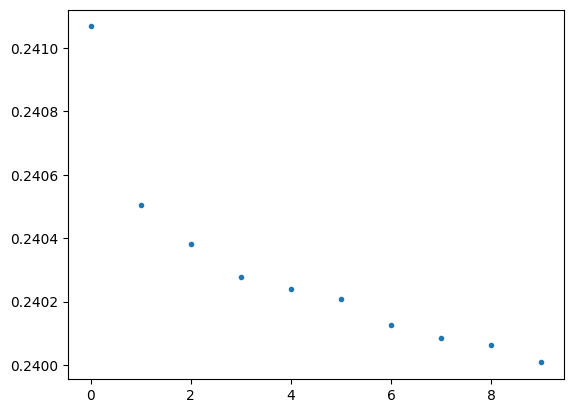

In [ ]:
plt.plot(losses, '.')

In [ ]:
count_experts = gatings_pred.shape[1]
gatings_pred.shape

(2138380, 6)

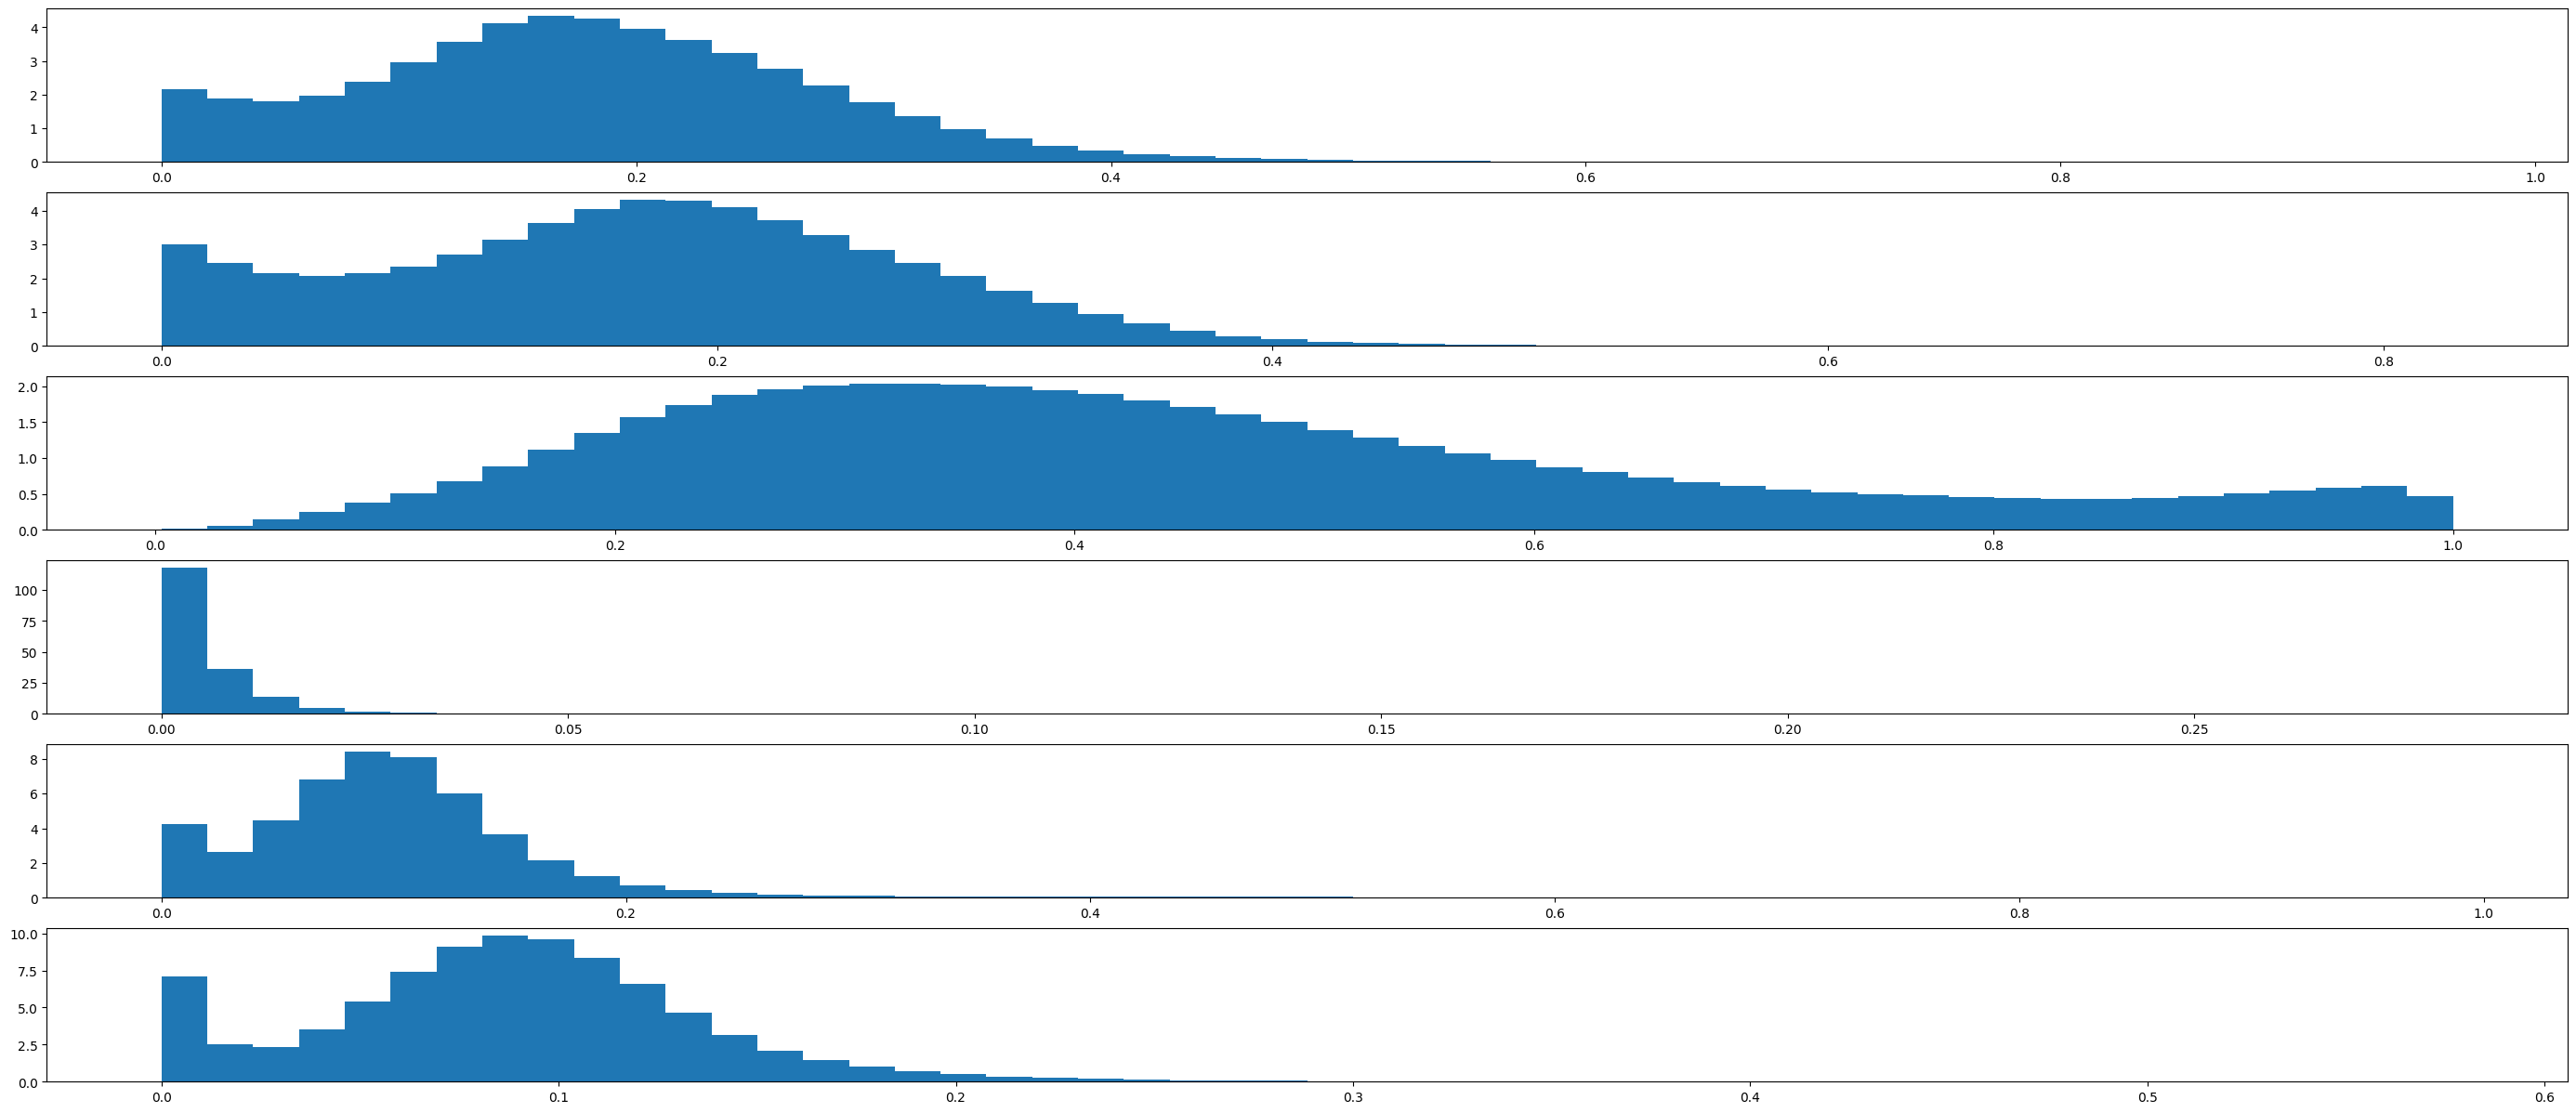

In [ ]:
fig, ax = plt.subplots(nrows=count_experts, ncols=1, figsize=(35, 15))
for i in range(count_experts):
    ax[i].hist(gatings_pred[:, i], bins=50, density=True)

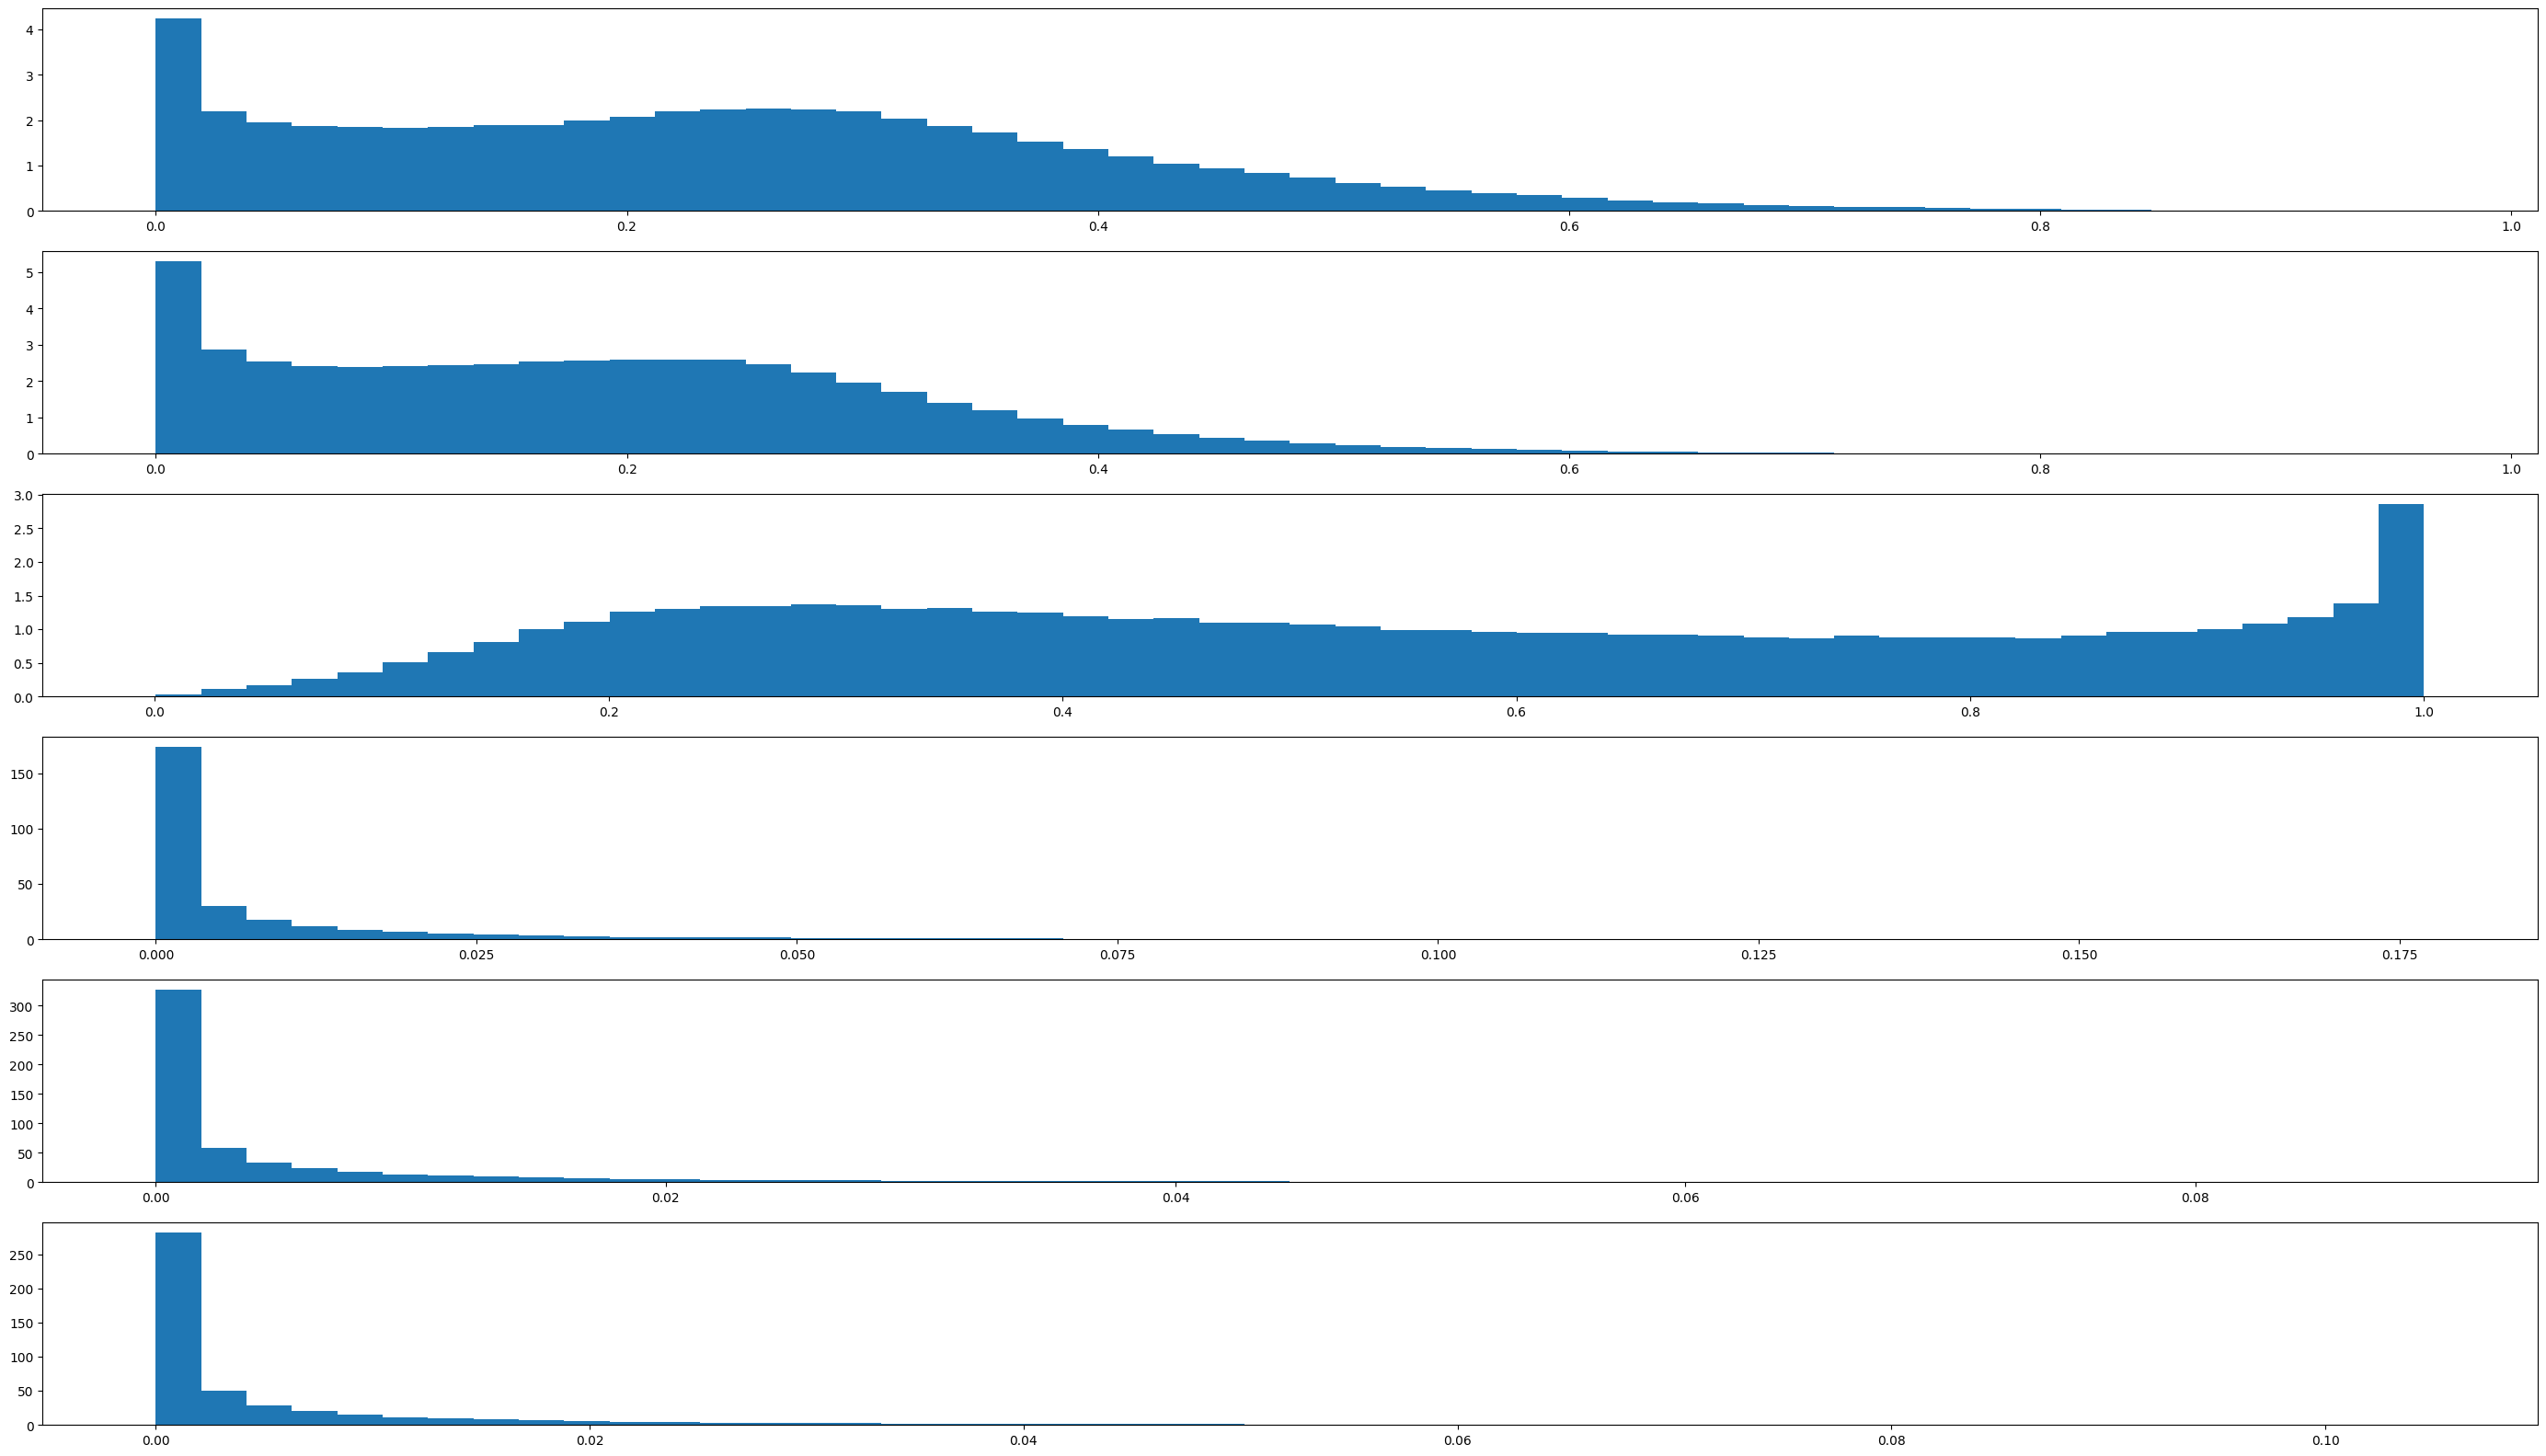

In [ ]:
fig, ax = plt.subplots(nrows=count_experts, ncols=1, figsize=(35, 20))
for i in range(count_experts):
    ax[i].hist(last_gatings_pred[:, i], bins=50, density=True)

(array([[2.93590e+04, 7.76500e+03, 5.01500e+03, 3.67100e+03, 2.96700e+03,
         2.48400e+03, 2.13700e+03, 1.98300e+03, 1.79200e+03, 1.72600e+03,
         1.69300e+03, 1.68600e+03, 1.66800e+03, 1.78800e+03, 1.93400e+03,
         2.14800e+03, 2.56600e+03, 3.21200e+03, 5.02100e+03, 1.33223e+05],
        [1.38076e+05, 5.86000e+03, 4.18700e+03, 3.53200e+03, 3.63300e+03,
         3.86100e+03, 4.98700e+03, 8.48300e+03, 1.25840e+04, 1.18570e+04,
         9.29600e+03, 5.31400e+03, 1.79900e+03, 2.70000e+02, 5.90000e+01,
         2.70000e+01, 1.30000e+01, 0.00000e+00, 0.00000e+00, 0.00000e+00],
        [1.38542e+05, 5.75400e+03, 4.05600e+03, 3.49900e+03, 3.32900e+03,
         3.57700e+03, 4.46700e+03, 7.23100e+03, 1.21800e+04, 1.60320e+04,
         1.17810e+04, 3.14700e+03, 2.29000e+02, 1.30000e+01, 1.00000e+00,
         0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00]]),
 array([1.41531145e-43, 5.00000000e-02, 1.00000000e-01, 1.50000000e-01,
        2.00000000e-01, 2.50000000e

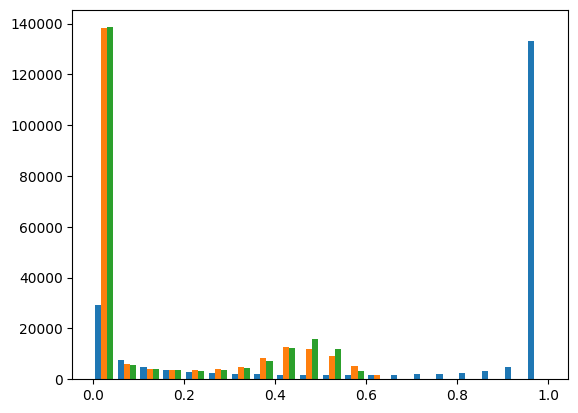

In [ ]:
plt.hist(last_gatings_pred, bins=20, histtype='bar')

In [ ]:
proba, gatings_pred_test_train, _ = moe.predict_proba(X_test)
print(roc_auc_score(y_true=Y_test, y_score=proba))
proba_experts, _, _ = moe.predict_proba(X_experts)
print(roc_auc_score(y_true=Y_experts, y_score=proba_experts))
proba_gating, _, _ = moe.predict_proba(X_gating)
print(roc_auc_score(y_true=Y_gating, y_score=proba_gating))
#0.926
#0.9255
# LB score: 0.92419
#TabM, XGBoost, LGBoost, CatBoost
"""
0.9255908094870438
0.9262724431646728
0.926076551843604
"""
#0.9255072902107921
print()

0.9244776205392334
0.9263871372090674
0.9246493945544267



Start decission

0.9243600698378827

0.9300415484541156

0.9244577851254727

In [ ]:
logistic_model = LogisticRegression(random_state=42, C=0.0001)
logistic_model.fit(np.concatenate([X_experts, X_gating], axis=0), np.concatenate([Y_experts, Y_gating], axis=0))
pred = logistic_model.predict_proba(X_test)[:, 1]
print(roc_auc_score(y_true=Y_test, y_score=pred))
pred = logistic_model.predict_proba(X_experts)[:, 1]
print(roc_auc_score(y_true=Y_experts, y_score=pred))

0.7912085763036185
0.7913277118408233


In [ ]:
result, gatings_pred_test, _ = moe.predict_proba(test.values)

In [ ]:
result_df = pd.DataFrame({
    "id" : test_["id"],
    "loan_paid_back" : result
})
result_df.to_csv("/content/drive/MyDrive/ML_data/predict_loan_payback/submission.csv", index=False)

# Merge submission

In [ ]:
import pandas as pd
import numpy as np

artem_vlad_submission = pd.read_csv("/content/drive/MyDrive/ML_data/predict_loan_payback/submission_merged_new.csv")
my_submission = pd.read_csv("/content/drive/MyDrive/ML_data/predict_loan_payback/submission_xgb_lgb_cat_tabm_my_fe.csv")
my_kdmitriev_submission = pd.read_csv("/content/drive/MyDrive/ML_data/predict_loan_payback/submission_xgb_lgb_cat_tabm_moe_kdmitriev_fe.csv")

In [ ]:
all_submit = np.zeros(len(my_kdmitriev_submission), dtype=np.float64)
for data in [artem_vlad_submission, my_kdmitriev_submission]:
    all_submit = all_submit + data[data.columns[1]] / 2
final = my_submission.copy()
final[final.columns[1]] = all_submit
final.to_csv("/content/drive/MyDrive/ML_data/predict_loan_payback/submission.csv", index=False)